In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

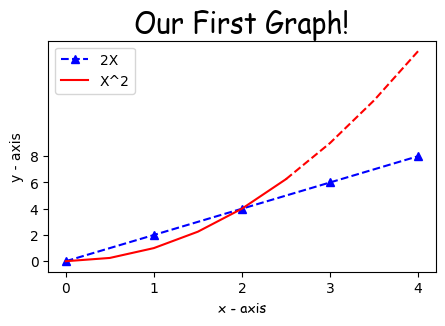

In [4]:
### Basic 
x = [0,1,2,3,4]
y = [0,2,4,6,8]

# resize the plot
plt.figure(figsize= (5,3), dpi = 100) # 5inches by 3inches and dpi is pixels per inch makes dpis smalller

# plt.plot(x,y,label="2X",color='red', linewidth=2, marker='.', linestyle='--' ,markeredgecolor='blue')

#shorthand notation
# fmt = '[color][marker][line]'
plt.plot(x,y,'b^--',label='2X')

## line number two
x2 = np.arange(0,4.5,0.5)

plt.plot(x2[:6],x2[:6]**2, 'r', label = 'X^2')
plt.plot(x2[5:],x2[5:]**2, 'r--')

plt.title("Our First Graph!", fontdict={"fontname":'Comic sans MS','fontsize':20})
plt.xlabel("x - axis", fontdict={'fontname':'Comic sans MS'})
plt.ylabel("y - axis")

plt.xticks([0,1,2,3,4])
plt.yticks([0,2,4,6,8])
plt.legend()

plt.savefig('mygraph.png', dpi = 300)
plt.show()


### Bar Charts

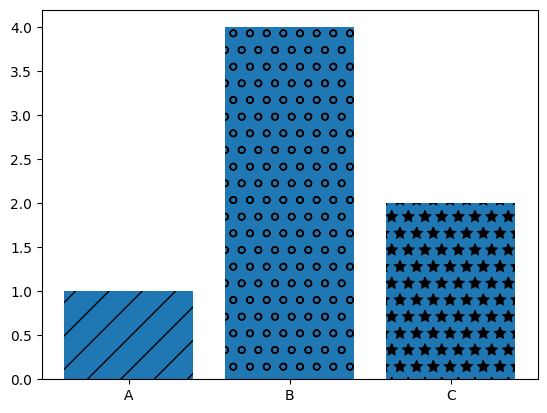

<Figure size 600x400 with 0 Axes>

In [5]:
labels = ['A','B','C']
values = [1,4,2]
bars = plt.bar(labels,values)


patterns = ['/','o','*']
for bar in bars:
    bar.set_hatch(patterns.pop(0))

# bars[0].set_hatch('/')
# bars[1].set_hatch('o')
# bars[2].set_hatch('*')

plt.figure(figsize=(6,4))

plt.show()

# Real World Examples  

### Gas Price Data

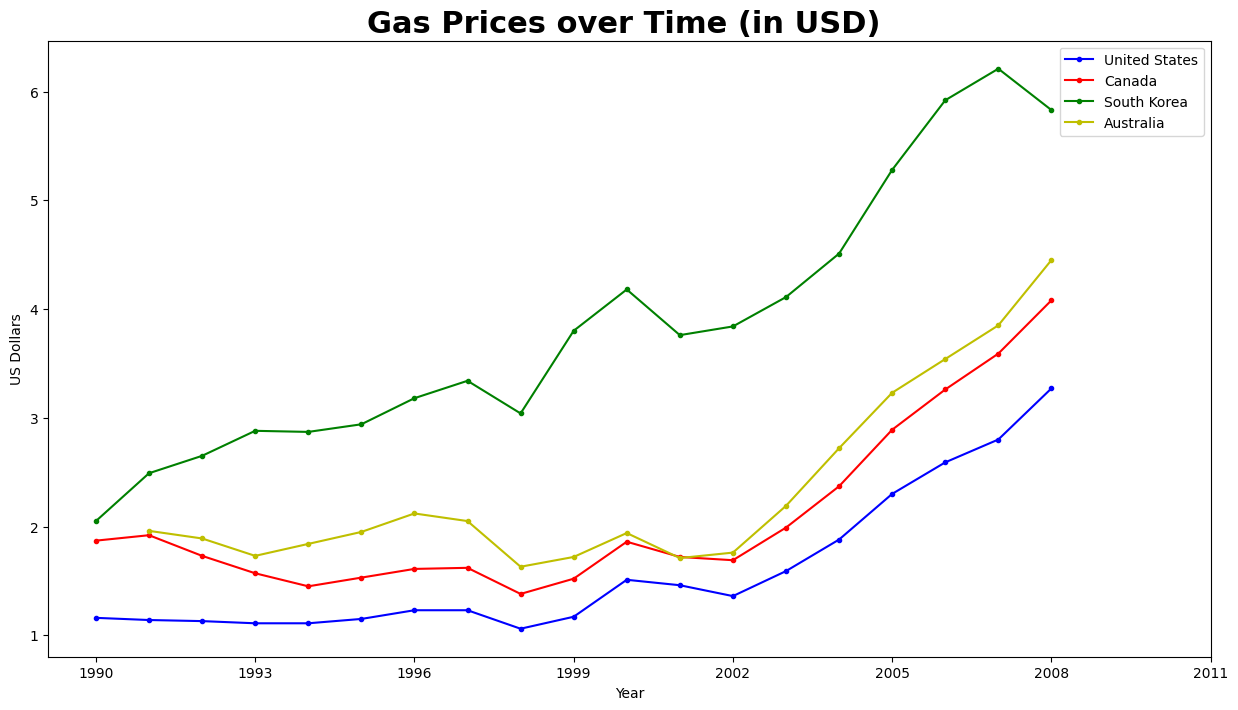

In [6]:
gas = pd.read_csv('gas_prices.csv')

plt.figure(figsize=(15,8))

plt.title('Gas Prices over Time (in USD) ' , fontdict={'fontweight':'bold', 'fontsize':22})

plt.plot(gas.Year,gas.USA, 'b.-', label='United States')
plt.plot(gas.Year,gas.Canada,'r.-', label='Canada')
plt.plot(gas.Year, gas['South Korea'], 'g.-', label='South Korea') #use these brackets for bigger two or bigger names
plt.plot(gas.Year,gas.Australia, 'y.-', label='Australia')

# for country in gas:
#     if country!='Year':
#         plt.plot(gas.Year, gas[country], marker='.', label = country)


# countries_to_look_at = ['Australia','USA','Canada','South Korea']
# for country in gas:
#     if country in countries_to_look_at:
#         plt.plot(gas.Year, gas[country], marker='.', label = country)

# print(gas.Year[::3])
plt.xticks(gas.Year[::3].tolist()+[2011]) # every 3 years gap

plt.xlabel('Year')
plt.ylabel('US Dollars')

plt.legend()

plt.savefig('Gas_price_figure.png',dpi=300)

plt.show()

### Fifa Data

In [7]:
fifa = pd.read_csv('fifa_data.csv')
fifa.head(3)

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M


### Histogram

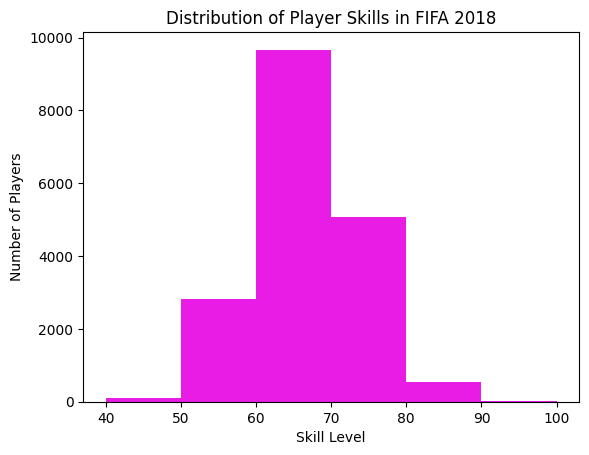

In [8]:
bins = [40,50,60,70,80,90,100]

plt.hist(fifa.Overall, bins=bins, color='#e81ce5')
plt.xticks(bins)
plt.yticks()
plt.ylabel('Number of Players')
plt.xlabel('Skill Level')
plt.title('Distribution of Player Skills in FIFA 2018')
plt.show()

### Piecharts

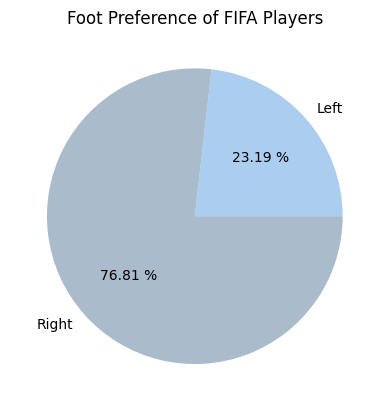

In [9]:
# left = fifa.loc[fifa['Preferred Foot']=='Left'].count()[0]
left = (fifa['Preferred Foot'] == 'Left').sum()
right = (fifa['Preferred Foot'] == 'Right').sum()

labels = ['Left','Right']
colors = ['#abcdef', '#aabbcc']

plt.pie([left,right] , labels = labels, colors=colors, autopct = '%.2f %%')
plt.title('Foot Preference of FIFA Players')

plt.show()

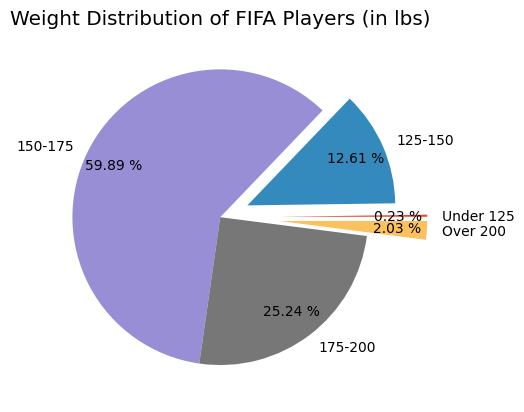

In [10]:

fifa.Weight = [int(x.strip('lbs')) if type(x)==str else x for x in fifa.Weight]
fifa['Weight'] = fifa['Weight'].astype('Int64')

plt.style.use('ggplot')

light = (fifa['Weight'] < 125).sum()
light_medium = ((fifa['Weight'] >= 125) & (fifa['Weight'] < 150)).sum()
medium = ((fifa['Weight'] >= 150) & (fifa['Weight'] < 175)).sum()
medium_heavy = ((fifa['Weight'] >= 175) & (fifa['Weight'] < 200)).sum()
heavy = (fifa['Weight'] > 200).sum()
explode =  (.4,.2,0,0,.4)
weights = [light,light_medium,medium,medium_heavy,heavy]
labels = ['Under 125', '125-150', '150-175', '175-200','Over 200']

plt.title('Weight Distribution of FIFA Players (in lbs)')
plt.pie(weights, labels = labels, autopct='%.2f %%', pctdistance = 0.8, explode=explode)

plt.show()

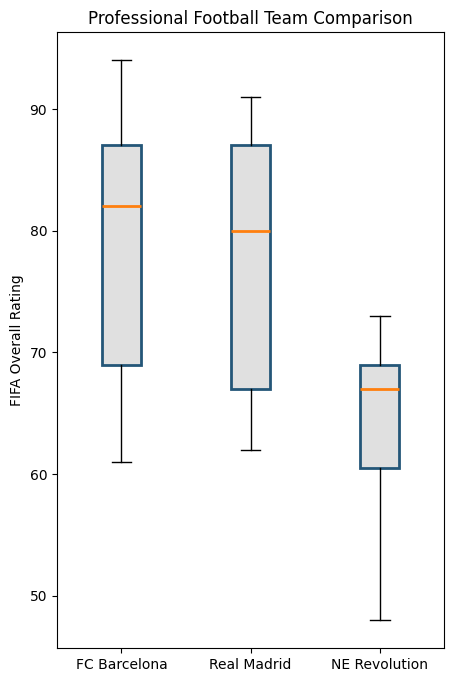

In [26]:
plt.style.use('default')

plt.figure(figsize = (5,8))
barcelona = fifa.loc[fifa.Club == 'FC Barcelona']['Overall']
madrid = fifa.loc[fifa.Club == 'Real Madrid']['Overall']
revs =fifa.loc[fifa.Club == 'New England Revolution']['Overall']
labels = [ 'FC Barcelona','Real Madrid','NE Revolution']

plt.title('Professional Football Team Comparison')
plt.ylabel('FIFA Overall Rating')

boxes = plt.boxplot([barcelona, madrid,revs],tick_labels=labels, patch_artist = True, medianprops = {'linewidth':2})
for box in boxes['boxes']:
    box.set(color = '#245678', linewidth = 2)

    box.set(facecolor = '#e0e0e0')
plt.show()